In [1]:
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
import torch
import intel_extension_for_pytorch as ipex
from ultralytics import YOLO
from PIL import Image
device = 'xpu'
model_path='weights/icon_detect/model.pt'

som_model = get_yolo_model(model_path)

som_model.to(device)

print('model to {}'.format(device))

c:\Users\sdp\miniforge3\envs\omni-ipex\Lib\site-packages\torchvision\io\image.py:14: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\sdp\miniforge3\envs\omni-ipex\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
[2025-02-25 03:50:44,830] [ WARNING] easyocr.py:80 - Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


model to xpu


In [2]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
caption_model_processor = get_caption_model_processor(model_name="florence2", model_name_or_path="weights/icon_caption_florence", device=device)



Florence2LanguageForConditionalGeneration has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [3]:
som_model.device, type(som_model) 

(device(type='xpu', index=0), ultralytics.models.yolo.model.YOLO)

In [7]:
# reload utils
import importlib
import utils
importlib.reload(utils)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

image_path = 'imgs/google_page.png'
image_path = 'imgs/booking.png'
# image_path = 'imgs/windows_home.png'
# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
# image_path = 'imgs/ios.png'
#image_path = 'imgs/word.png'
# image_path = 'imgs/excel2.png'

image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05

import time
start = time.time()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
cur_time_ocr = time.time() 

dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)
cur_time_caption = time.time() 


image size: (3840, 2160)

0: 736x1280 64 icons, 1539.4ms
Speed: 9.0ms preprocess, 1539.4ms inference, 7.1ms postprocess per image at shape (1, 3, 736, 1280)
len(filtered_boxes): 70 28
time to get parsed content: 1.2964661121368408


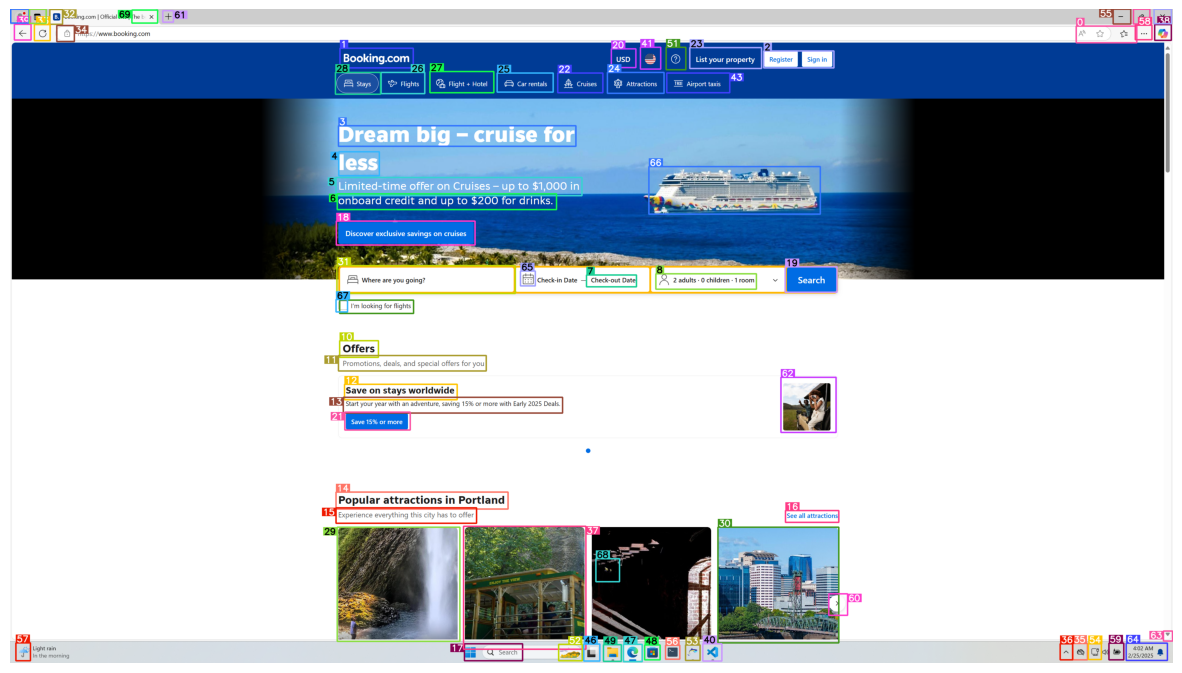

In [8]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [9]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,source,ID
0,text,"[0.9166666865348816, 0.025925925001502037, 0.9...",False,A,box_ocr_content_ocr,0
1,text,"[0.2835937440395355, 0.06018518656492233, 0.34...",False,Booking.com,box_ocr_content_ocr,1
2,text,"[0.6479166746139526, 0.06435184925794601, 0.70...",False,Registersign in,box_ocr_content_ocr,2
3,text,"[0.2822916805744171, 0.17824074625968933, 0.48...",False,Dream big - cruise for,box_ocr_content_ocr,3
4,text,"[0.2825520932674408, 0.21805556118488312, 0.31...",False,less,box_ocr_content_ocr,4
...,...,...,...,...,...,...
65,icon,"[0.43889495730400085, 0.4009016752243042, 0.45...",True,Calendar,box_yolo_content_yolo,65
66,icon,"[0.5494651794433594, 0.2410052865743637, 0.696...",True,A large building or structure.,box_yolo_content_yolo,66
67,icon,"[0.2802828848361969, 0.4442066550254822, 0.290...",True,Square,box_yolo_content_yolo,67
68,icon,"[0.5037468075752258, 0.8404149413108826, 0.524...",True,Night mode,box_yolo_content_yolo,68


In [7]:
parsed_content_list

[{'type': 'text',
  'bbox': [0.09169496595859528,
   0.0046317740343511105,
   0.13738808035850525,
   0.028253821656107903],
  'interactivity': False,
  'content': 'G Google',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.08860759437084198,
   0.0407596118748188,
   0.18956467509269714,
   0.06252894550561905],
  'interactivity': False,
  'content': 'https://www.google.com',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.8264896869659424,
   0.0842982828617096,
   0.8913244605064392,
   0.10977303981781006],
  'interactivity': False,
  'content': 'GmailImages',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.016671812161803246,
   0.08893006294965744,
   0.050941649824380875,
   0.10606762021780014],
  'interactivity': False,
  'content': 'About',
  'source': 'box_ocr_content_ocr'},
 {'type': 'text',
  'bbox': [0.4146341383457184,
   0.3024548292160034,
   0.5875270366668701,
   0.39277443289756775],
  'interactivity': False,